# Data Understanding and Preparation 

Covers **Stage 1 (Dataset Understanding + EDA)** and **Stage 2 (Data Preparation)**. 
- Each stage below lists its **sub-tasks as a checklist**
- Complete every `# TODO` so each checklist item is satisfied
- Implement the reusable logic in `src/data_prep.py` and call it here so the same code backs your notebook and the later stages

**File ownership** — 
- *Provided (no change needed):* `config.py` (paths, target, column lists, params)
- *Provided to extend:* `src/data_prep.py` (function stubs)
- *You create:* the cells below + the report sections

**Business context:** flag diabetic inpatients at risk of 30-day readmission so care teams can intervene. The target is highly imbalanced (~9%), so metric choice and leakage prevention matter.

# Stage 1 - Business & Data Understanding, EDA, and Methodology  <font color="red">[20 marks]</font>

> **Stage 1 also has report-only tasks** graded from the MLOps report, not this notebook: **1.1 Business Understanding** (1.1.1–1.1.3) and **1.4 Methodology Design** (1.4.1–1.4.2).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import config as cfg
from src import data_prep as dp
raw = dp.load_raw()
print('raw shape:', raw.shape)
raw.head(3)

raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## Stage 1.2 — Dataset Understanding <font color="red">[4 marks]</font>

- **1.2.1 — Dataset structure, target derivation & patients-vs-encounters [2]** — print the shape (~101,766 × 50), derive the target (`readmitted` `<30` → 1), and compare unique patients (`patient_nbr`) vs encounters.
- **1.2.2 — Feature types & data-quality / missing-value quantification [2]** — summarise feature types and build a per-column missing-value table with percentages (note `?` was loaded as NaN; e.g. `weight` ~97% missing).

In [2]:
print('rows:', len(raw), '| columns:', raw.shape[1])
print('unique patients:', raw['patient_nbr'].nunique(), '| encounters:', raw['encounter_id'].nunique())
raw['readmitted'].value_counts()

rows: 101766 | columns: 50
unique patients: 71518 | encounters: 101766


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

30-day readmission rate: 11.16%


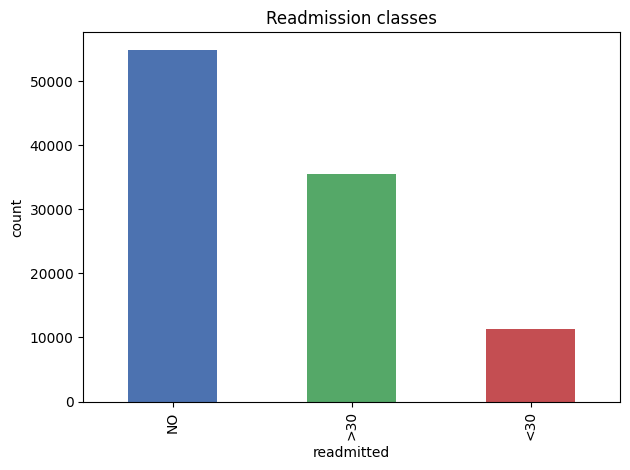

In [3]:
y = (raw['readmitted']=='<30').astype(int)
print('30-day readmission rate: %.2f%%' % (100*y.mean()))
ax = raw['readmitted'].value_counts().plot(kind='bar', color=['#4C72B0','#55A868','#C44E52'])
ax.set_title('Readmission classes'); ax.set_ylabel('count'); plt.tight_layout()
plt.savefig(cfg.ARTIFACT_DIR/'eda_target.png', dpi=90); plt.show()

## Stage 1.3 — Exploratory Data Analysis <font color="red">[7 marks]</font>
- **1.3.1 — Univariate analysis [3]** — visualise the target imbalance and ≥3 numeric feature distributions, with brief observations.
- **1.3.2 — Bivariate analysis vs target [2]** — analyse ≥1 relationship to the target (e.g. readmission rate vs prior inpatient visits) and interpret it.
- **1.3.3 — Visualisations + written interpretation [2]** — clear, labelled plots; interpret each key finding in writing (see the interpretation cell below).

In [3]:
miss = raw.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)

display(
    pd.DataFrame({
        "Missing Count": miss
    })
)

,Missing Count
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


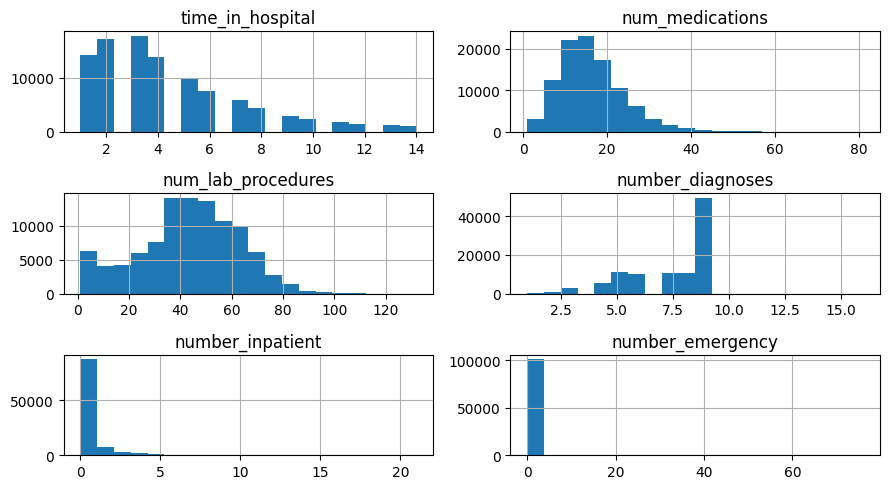

In [5]:
num = ['time_in_hospital','num_medications','num_lab_procedures','number_diagnoses',
       'number_inpatient','number_emergency']
raw[num].hist(bins=20, figsize=(9,5)); plt.tight_layout()
plt.savefig(cfg.ARTIFACT_DIR/'eda_numeric.png', dpi=90); plt.show()

In [9]:
# Bivariate: readmission rate rises with prior inpatient visits



### ✍️ Interpretation
- The target is highly imbalanced (~9% after cleaning) → **ROC-AUC / PR-AUC / recall** matter more than accuracy.
- `weight` is ~97% missing (drop); `medical_specialty`/`payer_code` ~40-50% missing.


## Stage 2 — Data Preparation  <font color="red">[25 marks]</font>

## Stage 2.1 — Data Cleaning <font color="red">[6 marks]</font>
Implement `clean()` in `src/data_prep.py`, then call it here.

- **2.1.1 — Missing value handling & invalid value treatment [2]** — `?`→NaN; drop `weight` and constant/zero-variance medication columns.
- **2.1.2 — Patient deduplication & removal of invalid records [2]** — keep the FIRST encounter per patient (`drop_duplicates('patient_nbr')`, prevents leakage); drop expired/hospice discharges (`discharge_disposition_id` ∈ {11,13,14,19,20,21}).
- **2.1.3 — Target variable creation & validation [2]** — build the binary target and validate its class balance (expect ~69,973 rows, ~9% positive).

In [11]:
clean = dp.clean(raw)
print('after cleaning:', clean.shape, '| target rate: %.2f%%' % (100*clean[cfg.TARGET].mean()))
clean[[cfg.TARGET]].value_counts()

after cleaning: (69973, 38) | target rate: 8.97%


readmitted_30d
0                 63696
1                  6277
Name: count, dtype: int64

## Stage 2.2 — Feature Engineering <font color="red">[8 marks]</font>
Implement `engineer_features()` in `src/data_prep.py`.

- **2.2.1 — ICD-9 diagnosis grouping into clinical categories [4]** — group `diag_1/2/3` into clinical categories (circulatory, respiratory, diabetes, injury, other) with a justified mapping.
- **2.2.2 — Additional engineered features, justified [4]** — ≥3 of {age midpoint, service_utilization, num_med_changes, medical_specialty top-k grouping}, each justified.

In [12]:
fe = dp.engineer_features(clean)
fe[['service_utilization']].head()

,service_utilization
8,0
9,0
4,0
10,0
5,0


In [14]:
print("service_utilization" in fe.columns)
print("num_med_changes" in fe.columns)

True
True


## Stage 2.3 — Feature Transformation <font color="red">[5 marks]</font>
Implement `build_preprocessor()` in `src/data_prep.py`.

- **2.3.1 — Numeric scaling & categorical encoding [3]** — numeric: median-impute + scale; categorical: impute + `OneHotEncoder(handle_unknown='ignore')`.
- **2.3.2 — Leakage-safe ColumnTransformer/Pipeline assembly [2]** — assemble ONE ColumnTransformer; do **not** fit it yet (fitting happens on the train split only, in 2.4).

## Stage 2.4 — Validation & Splitting <font color="red">[6 marks]</font>
Implement `get_splits()` in `src/data_prep.py`.

- **2.4.1 — Stratified train/validation/test split created first [3]** — STRATIFIED split BEFORE any fitting (`random_state=42`; class ratio preserved).
- **2.4.2 — Leakage-safe fit-on-train + class-balance check [3]** — fit the preprocessor on TRAIN only, transform val/test; confirm the class ratio is preserved across splits.

In [13]:
Xtr, Xv, Xte, ytr, yv, yte = dp.get_splits(fe)

num_f, cat_f = dp.get_feature_lists(fe)

pre = dp.build_preprocessor(
    num_f,
    cat_f
)

Xt = pre.fit_transform(Xtr)

print(
'train %d | val %d | test %d -> %d engineered features'
% (
    len(Xtr),
    len(Xv),
    len(Xte),
    Xt.shape[1]
)
)

train 44782 | val 11196 | test 13995 -> 156 engineered features


**Outputs saved to `artifacts/` for the modelling notebook and the report.**